Dataset preview:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  Setosa  
1  Setosa  
2  Setosa  
3  Setosa  
4  Setosa  


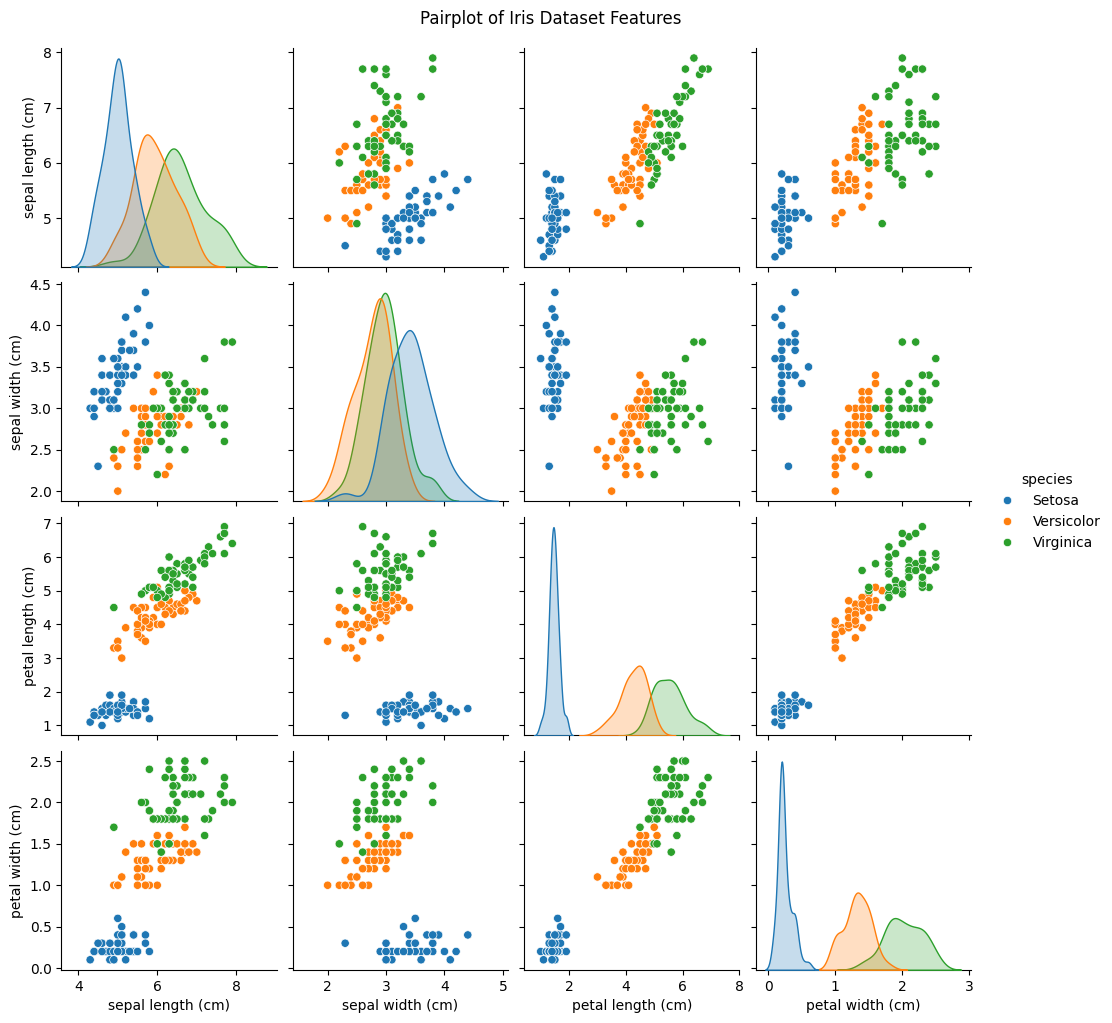

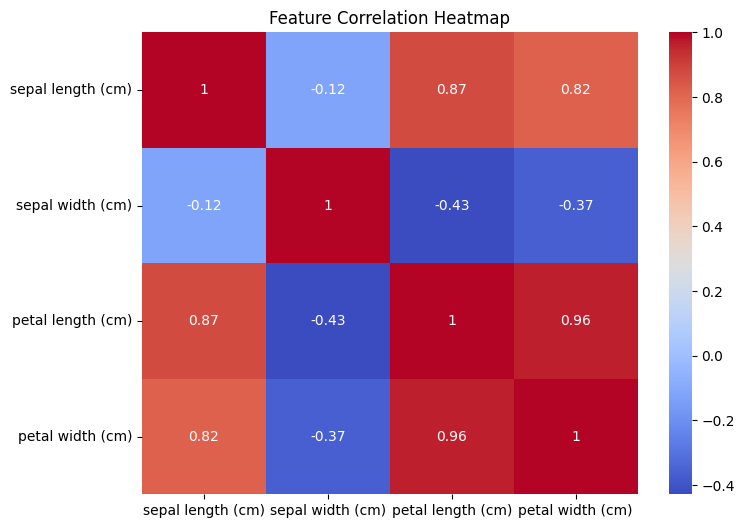

Model Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



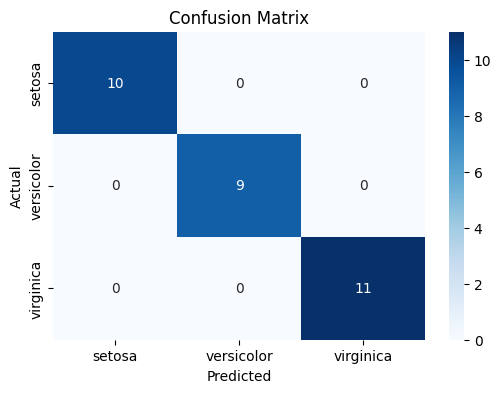

/tmp/ipython-input-1156938561.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance (Variance Contribution)', y='Feature', palette="viridis")


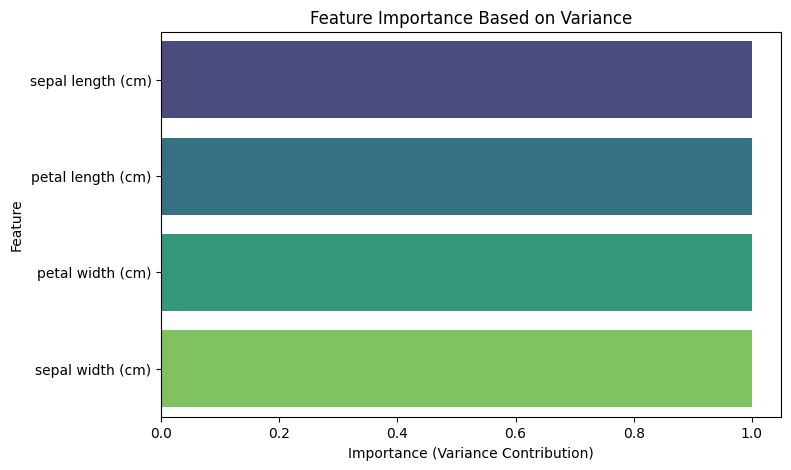


Model and Scaler saved successfully!
Saved files: iris_knn_model.pkl, iris_scaler.pkl


In [1]:
# -------------------------------------------------------
# IRIS FLOWER CLASSIFICATION USING KNN
# Machine Learning | Data Visualization | Evaluation
# -------------------------------------------------------

# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
df['species'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset preview:")
print(df.head())

# -------------------------------------------------------
# Exploratory Data Analysis (EDA)
# -------------------------------------------------------
sns.pairplot(df, hue='species', diag_kind='kde')
plt.suptitle("Pairplot of Iris Dataset Features", y=1.02)
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# -------------------------------------------------------
# Train-Test Split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

# -------------------------------------------------------
# Standardization
# -------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------------------------------
# Model Training (K-Nearest Neighbors)
# -------------------------------------------------------
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)

# -------------------------------------------------------
# Predictions & Model Evaluation
# -------------------------------------------------------
y_pred = model.predict(X_test_scaled)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------------------------------
# Feature Importance Insight (Optional - based on variance)
# -------------------------------------------------------
feature_variance = np.var(X_train_scaled, axis=0)
importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance (Variance Contribution)': feature_variance
}).sort_values(by='Importance (Variance Contribution)', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance (Variance Contribution)', y='Feature', palette="viridis")
plt.title("Feature Importance Based on Variance")
plt.show()

# -------------------------------------------------------
# Save Model and Scaler
# -------------------------------------------------------
joblib.dump(model, "iris_knn_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")
print("\nModel and Scaler saved successfully!")
print("Saved files: iris_knn_model.pkl, iris_scaler.pkl")
